# Figures from the included summaries

This notebook redraws the paper's quantitative figures using only the
aggregated CSVs in `summaries/`. It needs no raw runs, no GPU and no model
downloads, so it works immediately after cloning.

Styling follows the original figure code. Selectivity and valid-response rate
are defined as in Appendix C:

```
p_valid = (correct + misled) / (correct + misled + neither)
S       = (correct - misled) / (correct + misled)
```

Two aggregation conventions are used, matching the original figure code:

- **Behavioural figures (2-6)** collapse the runs to one value per dataset and
  then average those, so error bars describe spread **across datasets**
  (standard deviation, or standard error in Figure 6). Spread is deliberately
  not taken over the raw runs: each condition contains both an image-target and
  a caption-target run, and those legitimately sit far apart, so a deviation
  over raw runs would report the image/caption gap rather than uncertainty.
- **Intervention figures (8, 14-16)** pool the underlying counts, because a
  strong intervention leaves the two target modalities with very different
  numbers of valid responses.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch

ROOT = Path.cwd()
while not (ROOT / "summaries").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
SUMMARIES = ROOT / "summaries"

behavioral = pd.read_csv(SUMMARIES / "behavioral.csv")
arbitrary = pd.read_csv(SUMMARIES / "behavioral_arbitrary_labels.csv")
transform = pd.read_csv(SUMMARIES / "transformation_vec.csv")
represent = pd.read_csv(SUMMARIES / "representation_analysis.csv")

FORMAL_MODEL_NAMES = {
    "llava-hf/llava-1.5-7b-hf": "LLaVA-1.5-7B",
    "Salesforce/instructblip-vicuna-7b": "InstructBLIP-7B",
    "Qwen/Qwen2.5-VL-3B-Instruct": "Qwen2.5-VL-3B",
    "Qwen/Qwen2.5-VL-7B-Instruct": "Qwen2.5-VL-7B",
    "Qwen/Qwen2.5-VL-32B-Instruct": "Qwen2.5-VL-32B",
    "llava-hf/llava-onevision-qwen2-7b-ov-hf": "LLaVA-OneVision-7B",
    "OpenGVLab/InternVL3-8B-hf": "InternVL3-8B",
    "OpenGVLab/InternVL3-14B-hf": "InternVL3-14B",
    "google/gemma-3-4b-it": "Gemma-3-4B",
    "google/gemma-3-12b-it": "Gemma-3-12B",
    "google/gemma-3-27b-it": "Gemma-3-27B",
}
# Models whose preprocessing inserts explicit image wrapper tokens get a star.
NO_WRAPPER_TOKENS = ("llava", "instructblip")
PERTURBATION_MODELS = ["OpenGVLab/InternVL3-14B-hf", "google/gemma-3-12b-it",
                       "Qwen/Qwen2.5-VL-32B-Instruct"]

for df in (behavioral, arbitrary):
    df["model_disp"] = df["model"].map(FORMAL_MODEL_NAMES).fillna(df["model"])
transform["model"] = transform["model"].str.replace("_", "/", n=1)
transform["model_disp"] = transform["model"].map(FORMAL_MODEL_NAMES).fillna(transform["model"])

print(f"{len(behavioral)} behavioral rows | {len(arbitrary)} arbitrary-label rows | "
      f"{len(transform)} intervention rows | {len(represent)} representation rows")

396 behavioral rows | 48 arbitrary-label rows | 1296 intervention rows | 16 representation rows


In [2]:
def _per_dataset(frame):
    """Collapse a set of runs to one selectivity value per dataset.

    Spread is always reported across datasets, never across the runs inside a
    dataset. That matters: a single condition contains both the image-target and
    caption-target runs, and those legitimately sit far apart, so a standard
    deviation taken over the raw runs would describe the image/caption gap
    rather than any measurement uncertainty.
    """
    f = frame.copy()
    f["selectivity"] = pd.to_numeric(f["selectivity"], errors="coerce")
    return f.dropna(subset=["selectivity"]).groupby("dataset")["selectivity"].mean()


def sel_mean(frame):
    """Mean selectivity, averaging datasets equally."""
    v = _per_dataset(frame)
    return v.mean() if len(v) else np.nan


def sel_err(frame, err="std"):
    """Spread across datasets: 'std' for Figures 2-5, 'sem' for Figure 6."""
    v = _per_dataset(frame)
    if len(v) < 2:
        return 0.0
    s = v.std(ddof=1)
    return s if err == "std" else s / np.sqrt(len(v))


def valid_mean(frame):
    v = pd.to_numeric(frame["p_valid"], errors="coerce").dropna()
    return v.mean() if len(v) else np.nan


def sel_pooled(frame):
    """Count-weighted selectivity over a set of runs.

    Used for the intervention figures. Under a strong intervention the two
    target modalities can end up with very different numbers of valid
    responses -- a run that answers "neither" most of the time contributes few
    valid predictions -- so those runs are weighted by how much they actually
    decided rather than counted equally.
    """
    valid = frame["correct"].sum() + frame["misled"].sum()
    return (frame["correct"].sum() - frame["misled"].sum()) / valid if valid else np.nan


UNPERT_COLOR, REMOVE_COLOR, SWAP_COLOR = "lightgray", "C4", "C6"
EDGECOLOR, LINEWIDTH, BAR_WIDTH, CAPSIZE = "black", 1.0, 0.75, 3
IMAGE_TGT_COLOR, CAPTION_TGT_COLOR = "C0", "C1"

## Figure 2 — source-modality selectivity across 11 VLMs

Unperturbed markers, inconsistent inputs, `image_caption` format. Points are
the mean across datasets with standard-deviation error bars; faint dots are the
individual dataset values. A star marks models with image wrapper tokens. The
right-hand panel gives the valid-response rate under inconsistent inputs and
under single-modality inputs.

/tmp/ipykernel_2120605/440043657.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


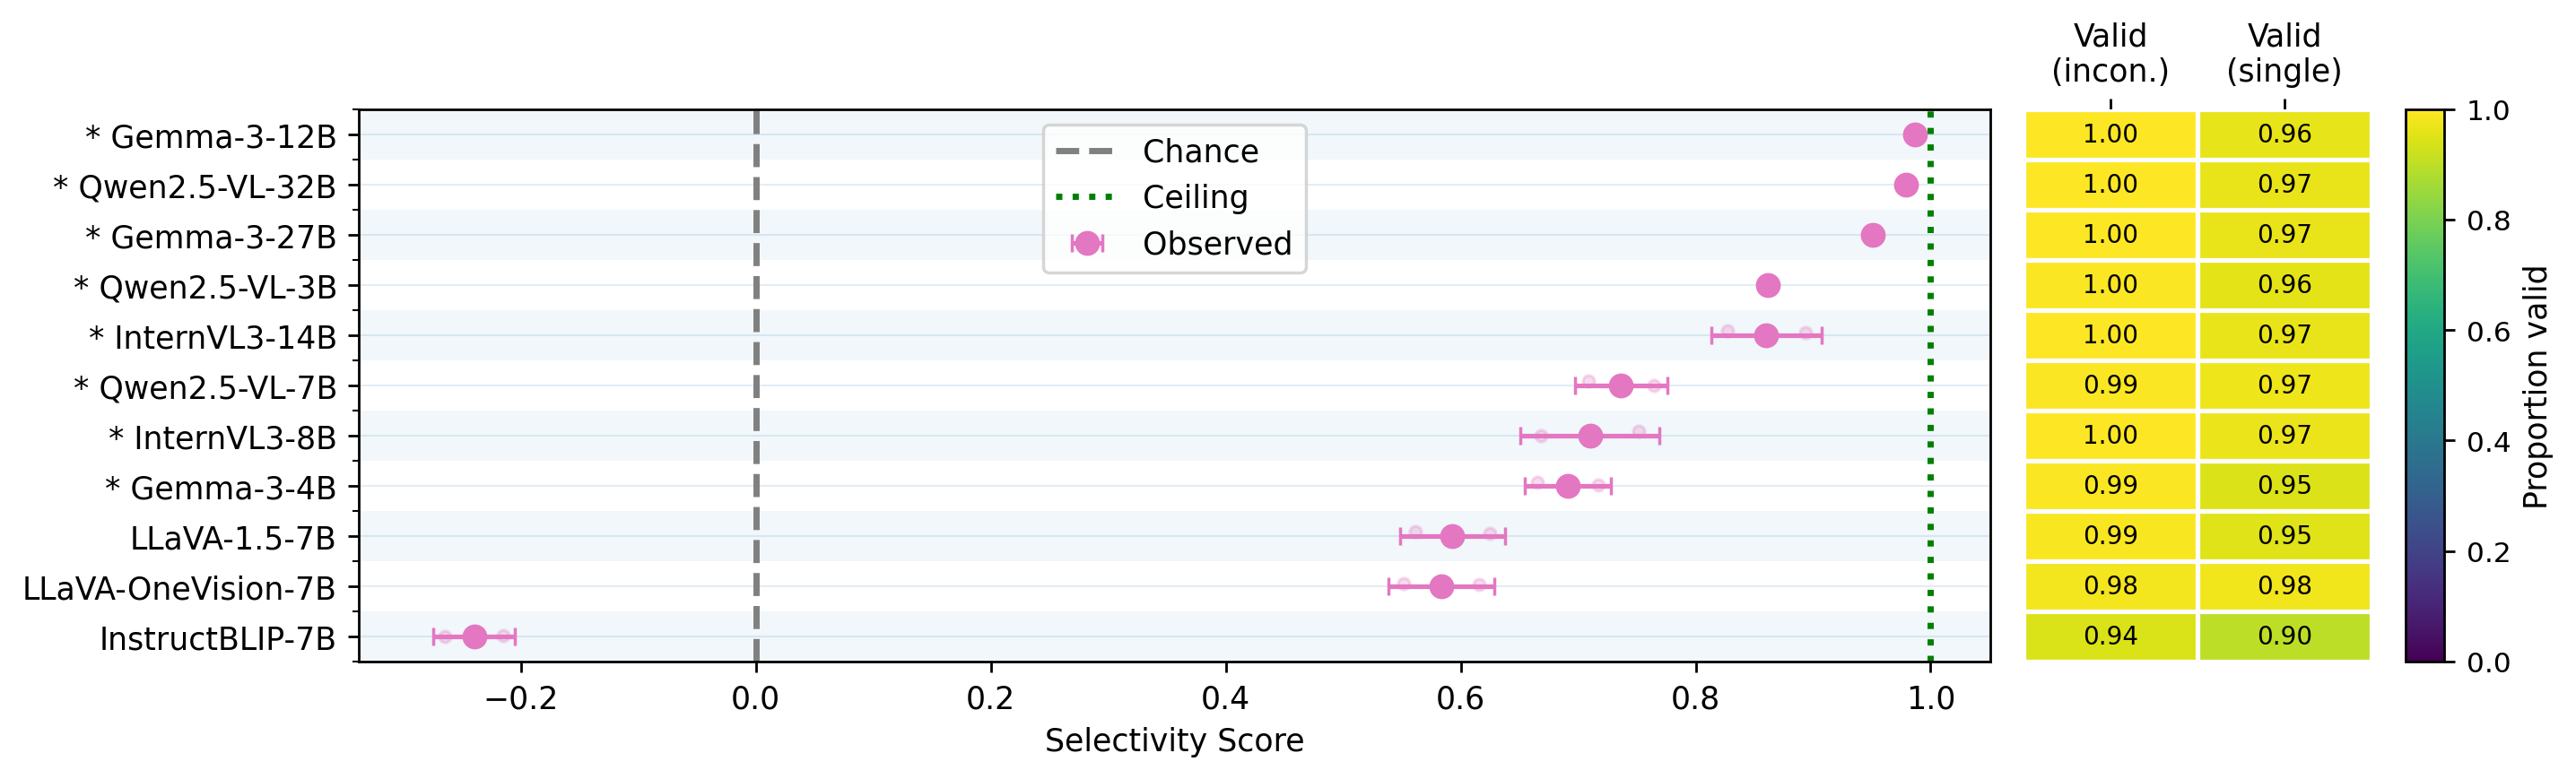

                    selectivity    std  valid_incon  valid_single
model_disp                                                       
Gemma-3-12B               0.987  0.001         1.00          0.96
Qwen2.5-VL-32B            0.979  0.003         1.00          0.97
Gemma-3-27B               0.951  0.003         1.00          0.97
Qwen2.5-VL-3B             0.861  0.002         1.00          0.96
InternVL3-14B             0.860  0.047         1.00          0.97
Qwen2.5-VL-7B             0.737  0.039         0.99          0.97
InternVL3-8B              0.710  0.059         1.00          0.97
Gemma-3-4B                0.691  0.037         0.99          0.95
LLaVA-1.5-7B              0.593  0.045         0.99          0.95
LLaVA-OneVision-7B        0.584  0.045         0.98          0.98
InstructBLIP-7B          -0.240  0.035         0.94          0.90


In [3]:
fig2 = behavioral.query("condition == 'none' and input_type == 'inconsistent' "
                        "and prompt_format == 'image_caption'")
single = behavioral.query("condition == 'none' and input_type in ['image_only', 'text_only'] "
                          "and prompt_format == 'image_caption'")

per_ds = (fig2.groupby(["model_disp", "dataset"])["selectivity"]
          .mean().rename("S").reset_index())
stats = per_ds.groupby("model_disp")["S"].agg(["mean", "std"]).fillna(0.0)
stats = stats.sort_values("mean", ascending=False)          # best first
models = stats.index.tolist()
y = (len(models) - 1) - np.arange(len(models), dtype=float)  # best at top

v_inc = fig2.groupby("model_disp").apply(valid_mean, include_groups=False)
v_sgl = single.groupby("model_disp").apply(valid_mean, include_groups=False)
heat = np.column_stack([v_inc.reindex(models).values, v_sgl.reindex(models).values])

fig = plt.figure(figsize=(12, max(3.2, 0.275 * len(models))), dpi=250)
gs = GridSpec(1, 3, width_ratios=[7.5, 1.6, 0.18], wspace=0.05)
ax, ax_hm, cax = fig.add_subplot(gs[0, 0]), None, None
ax_hm = fig.add_subplot(gs[0, 1], sharey=ax)
cax = fig.add_subplot(gs[0, 2])

for i in range(len(models)):
    if i % 2 == 0:
        ax.axhspan(y[i] - 0.5, y[i] + 0.5, alpha=0.06)
    ax.axhline(y[i], linewidth=0.5, alpha=0.15, zorder=0)

ax.errorbar(stats["mean"], y, xerr=stats["std"], fmt="o", capsize=CAPSIZE,
            label="Observed", markersize=7, color="C6")

rng = np.random.default_rng(0)
for i, m in enumerate(models):
    pts = per_ds[per_ds["model_disp"] == m]["S"].values
    ax.scatter(pts, y[i] + rng.uniform(0.0, 0.10, size=len(pts)),
               s=14, alpha=0.25, zorder=2, color="C6")

inv = {v: k for k, v in FORMAL_MODEL_NAMES.items()}
ylabels = [("" if any(t in inv.get(m, m).lower() for t in NO_WRAPPER_TOKENS) else "* ") + m
           for m in models]
ax.set_yticks(y)
ax.set_yticklabels(ylabels)
ax.set_xlabel("Selectivity Score")
ax.axvline(0.0, linewidth=2, linestyle="--", label="Chance", color="0.5")
ax.axvline(1.0, linewidth=2, linestyle=":", label="Ceiling", color="green")
ax.legend(loc="upper center", ncol=1)

im = ax_hm.imshow(np.flipud(heat), aspect="auto", interpolation="nearest",
                  vmin=0.0, vmax=1.0, origin="lower",
                  extent=[-0.5, 1.5, -0.5, len(models) - 0.5])
ax_hm.set_xticks([0, 1])
ax_hm.set_xticklabels(["Valid\n(incon.)", "Valid\n(single)"], fontsize=10)
ax_hm.tick_params(axis="x", top=True, bottom=False, labeltop=True, labelbottom=False)
ax_hm.tick_params(axis="y", left=False, labelleft=False)
for spine in ax_hm.spines.values():
    spine.set_visible(False)
ax_hm.set_xticks(np.arange(-0.5, 2, 1), minor=True)
ax_hm.set_yticks(np.arange(-0.5, len(models), 1), minor=True)
ax_hm.grid(which="minor", color="white", linewidth=1.5)
ax_hm.tick_params(which="minor", bottom=False, left=False)

disp = np.flipud(heat)
for i in range(len(models)):
    for j in range(2):
        r, g, b = im.cmap(im.norm(disp[i, j]))[:3]
        lum = 0.2126 * r + 0.7152 * g + 0.0722 * b
        ax_hm.text(j, i, f"{disp[i, j]:.2f}", ha="center", va="center",
                   fontsize=8, color="black" if lum > 0.55 else "white")

cb = fig.colorbar(im, cax=cax)
cb.set_label("Proportion valid", fontsize=10)
cb.ax.tick_params(labelsize=9)
ax.set_ylim(-0.5, len(models) - 0.5)
plt.tight_layout()
plt.show()

print(pd.DataFrame({"selectivity": stats["mean"].round(3), "std": stats["std"].round(3),
                    "valid_incon": v_inc.reindex(models).round(2),
                    "valid_single": v_sgl.reindex(models).round(2)}).to_string())

## Figure 3 — purely symbolic binding with arbitrary labels

Modality words are replaced by content-free labels, so retrieval can only
succeed by using the symbol as an index. `LabelA-LabelB` means LabelA is bound
to image content and LabelB to caption content.

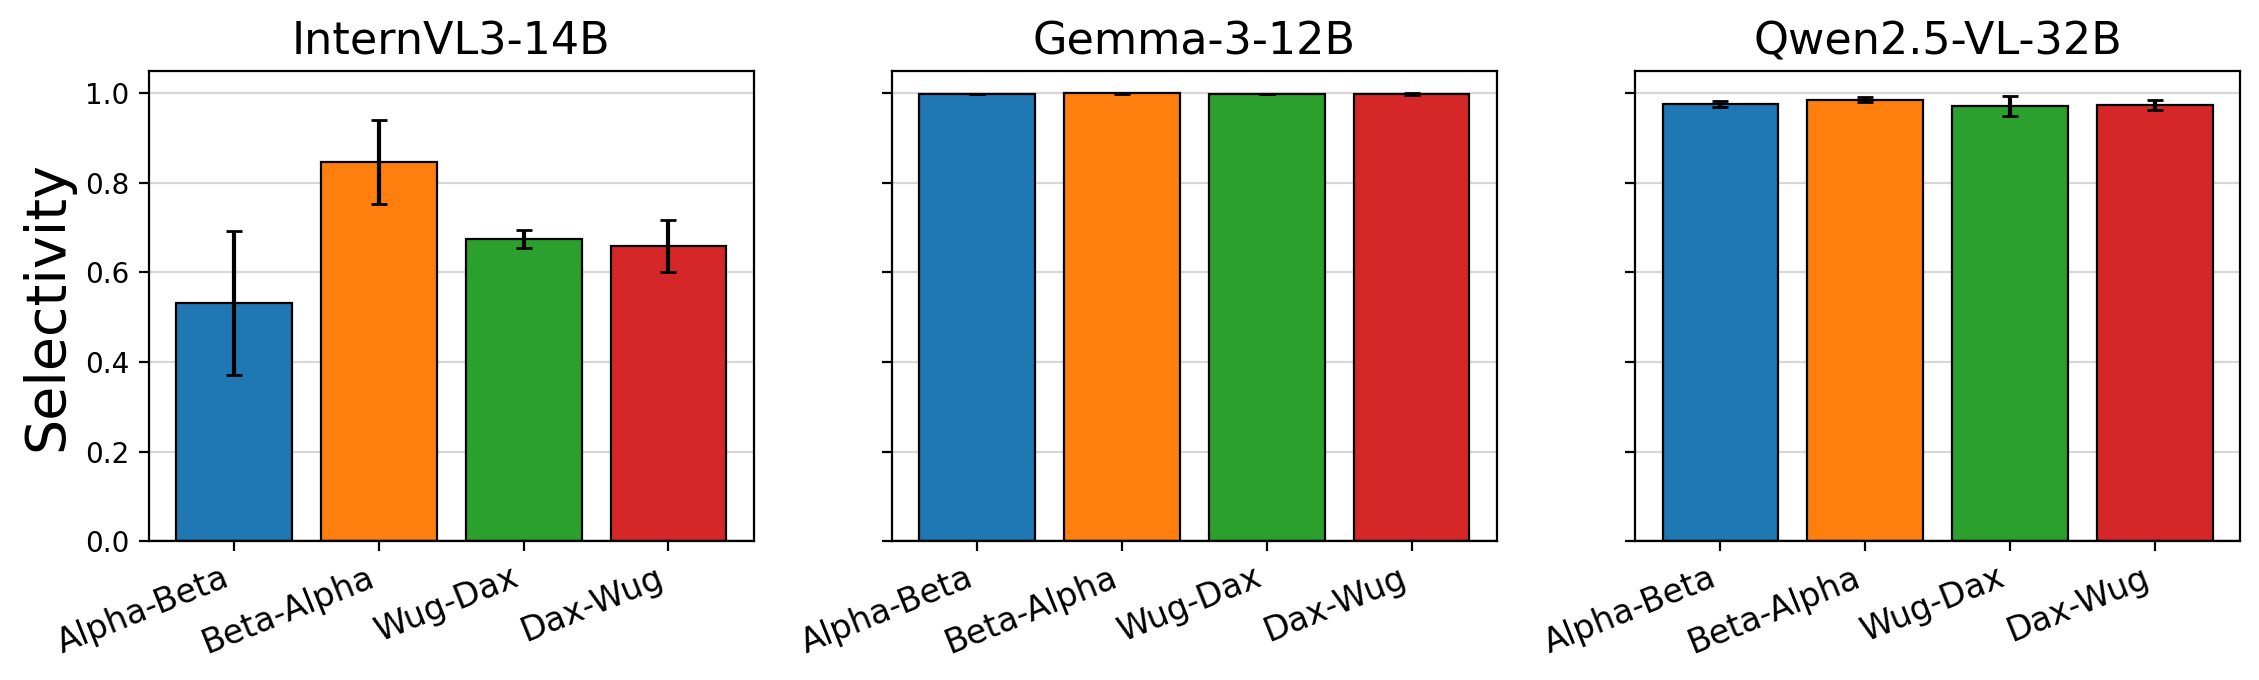

pair            Alpha-Beta  Beta-Alpha  Dax-Wug  Wug-Dax
model                                                   
Gemma-3-12B           1.00        1.00     1.00     1.00
InternVL3-14B         0.53        0.85     0.66     0.67
Qwen2.5-VL-32B        0.98        0.99     0.97     0.97


In [4]:
arb = arbitrary.assign(pair=arbitrary["label_1"] + "-" + arbitrary["label_2"])
PAIR_ORDER = ["Alpha-Beta", "Beta-Alpha", "Wug-Dax", "Dax-Wug"]
arb_models = [FORMAL_MODEL_NAMES[m] for m in PERTURBATION_MODELS
              if FORMAL_MODEL_NAMES[m] in set(arb["model_disp"])]
BAR_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

fig, axes = plt.subplots(1, len(arb_models), figsize=(3.8 * len(arb_models), 3.5),
                         dpi=200, sharey=True)
axes = np.atleast_1d(axes)
rows3 = []
for ax, model in zip(axes, arb_models):
    sub = arb[arb["model_disp"] == model]
    pairs = [p for p in PAIR_ORDER if p in set(sub["pair"])]
    vals = [sel_mean(sub[sub["pair"] == p]) for p in pairs]
    errs = [sel_err(sub[sub["pair"] == p]) for p in pairs]
    ax.bar(range(len(pairs)), vals, yerr=errs, color=BAR_COLORS[:len(pairs)],
           edgecolor="black", linewidth=0.8, capsize=CAPSIZE)
    ax.set_xticks(range(len(pairs)))
    ax.set_xticklabels(pairs, fontsize=12, rotation=22, ha="right")
    ax.set_title(model, fontsize=16)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.yaxis.grid(True, linestyle="-", alpha=0.5)
    ax.set_axisbelow(True)
    rows3 += [{"model": model, "pair": p, "S": v} for p, v in zip(pairs, vals)]
axes[0].set_ylabel("Selectivity", fontsize=20)
plt.tight_layout()
plt.show()

print(pd.DataFrame(rows3).pivot(index="model", columns="pair", values="S").round(2).to_string())

## Figure 4 — structural perturbation of the symbolic markers

The first two panels are the expectations under a purely symbolic account
(removal drops to chance, swapping reverses) and a purely distributional one
(markers are irrelevant). The observed models sit between the two. The final
panels split by target modality, where the asymmetry between image and caption
retrieval appears.

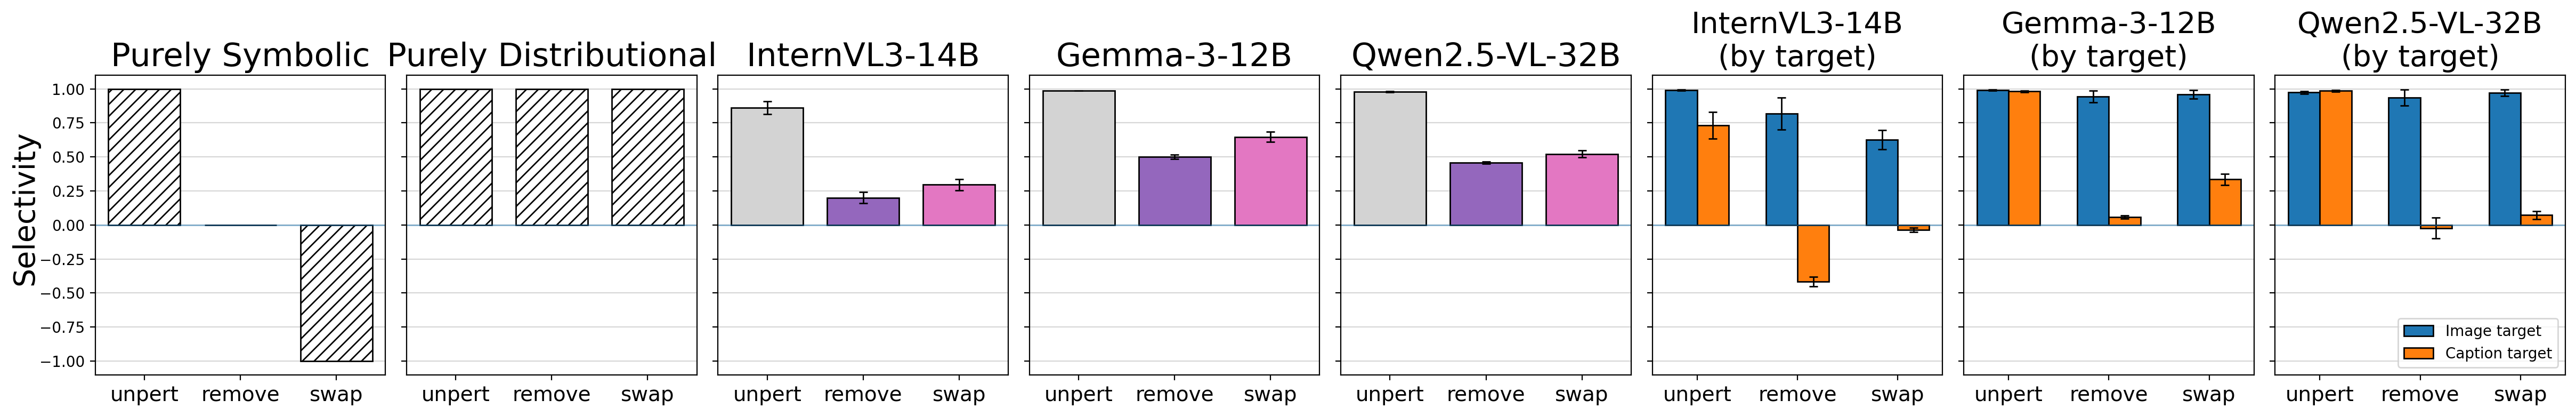

target                    image  text
model          condition             
Gemma-3-12B    remove      0.94  0.06
               swap        0.96  0.33
               unpert      0.99  0.98
InternVL3-14B  remove      0.82 -0.42
               swap        0.63 -0.04
               unpert      0.99  0.73
Qwen2.5-VL-32B remove      0.94 -0.02
               swap        0.97  0.07
               unpert      0.97  0.98


In [5]:
CONDS3 = ["none", "remove", "swap"]
XLAB3 = ["unpert", "remove", "swap"]
marker_df = behavioral.query("input_type == 'inconsistent' and prompt_format == 'image_caption'")
fig4_models = [FORMAL_MODEL_NAMES[m] for m in PERTURBATION_MODELS]
n_panels = 2 + len(fig4_models) * 2

fig, axes = plt.subplots(1, n_panels, figsize=(3.0 * n_panels, 4), dpi=200, sharey=True)
for ax, (vals, title) in zip(axes[:2], [([1.0, 0.0, -1.0], "Purely Symbolic"),
                                        ([1.0, 1.0, 1.0], "Purely Distributional")]):
    for b in ax.bar(range(3), vals, width=BAR_WIDTH):
        b.set_facecolor("white"); b.set_hatch("///")
        b.set_edgecolor(EDGECOLOR); b.set_linewidth(LINEWIDTH)
    ax.axhline(0.0, linewidth=1, alpha=0.5)
    ax.set_title(title, fontsize=22)
    ax.set_xticks(range(3)); ax.set_xticklabels(XLAB3, ha="center", fontsize=14)
    ax.yaxis.grid(True, linestyle="-", alpha=0.5); ax.set_axisbelow(True)

rows4 = []
for k, model in enumerate(fig4_models):
    sub = marker_df[marker_df["model_disp"] == model]
    ax = axes[2 + k]
    vals = [sel_mean(sub[sub["condition"] == c]) for c in CONDS3]
    errs = [sel_err(sub[sub["condition"] == c]) for c in CONDS3]
    bars = ax.bar(range(3), vals, yerr=errs, capsize=CAPSIZE, width=BAR_WIDTH,
                  error_kw=dict(ecolor="black", lw=1))
    for b, col in zip(bars, [UNPERT_COLOR, REMOVE_COLOR, SWAP_COLOR]):
        b.set_facecolor(col); b.set_edgecolor(EDGECOLOR); b.set_linewidth(LINEWIDTH)
    ax.axhline(0.0, linewidth=1, alpha=0.5)
    ax.set_title(model, fontsize=22)
    ax.set_xticks(range(3)); ax.set_xticklabels(XLAB3, ha="center", fontsize=14)
    ax.yaxis.grid(True, linestyle="-", alpha=0.5); ax.set_axisbelow(True)

    axs = axes[2 + len(fig4_models) + k]
    w = BAR_WIDTH * 0.42
    for sign, tgt, col, lab in [(-1, "image", IMAGE_TGT_COLOR, "Image target"),
                                (+1, "text", CAPTION_TGT_COLOR, "Caption target")]:
        v = [sel_mean(sub[(sub["condition"] == c) & (sub["target_modality"] == tgt)])
             for c in CONDS3]
        e = [sel_err(sub[(sub["condition"] == c) & (sub["target_modality"] == tgt)])
             for c in CONDS3]
        axs.bar([i + sign * w / 2 for i in range(3)], v, yerr=e, width=w, capsize=CAPSIZE,
                color=col, edgecolor=EDGECOLOR, linewidth=LINEWIDTH,
                error_kw=dict(ecolor="black", lw=1))
        rows4 += [{"model": model, "condition": c, "target": tgt, "S": x}
                  for c, x in zip(XLAB3, v)]
    axs.axhline(0.0, linewidth=1, alpha=0.5)
    axs.set_title(model + "\n(by target)", fontsize=20)
    axs.set_xticks(range(3)); axs.set_xticklabels(XLAB3, ha="center", fontsize=14)
    axs.yaxis.grid(True, linestyle="-", alpha=0.5); axs.set_axisbelow(True)

axes[-1].legend(handles=[Patch(facecolor=IMAGE_TGT_COLOR, edgecolor=EDGECOLOR, label="Image target"),
                         Patch(facecolor=CAPTION_TGT_COLOR, edgecolor=EDGECOLOR, label="Caption target")],
                fontsize=10, loc="lower right")
fig.text(-0.005, 0.5, "Selectivity", va="center", rotation="vertical", fontsize=20)
plt.tight_layout()
plt.show()

print(pd.DataFrame(rows4).pivot_table(index=["model", "condition"], columns="target",
                                      values="S").round(2).to_string())

## Figure 5 — alternative source-modality pairs

The same perturbations while varying the word used for the text source.
Markers matter far less when the text is called *text* than when it is called
*caption* or *document*.

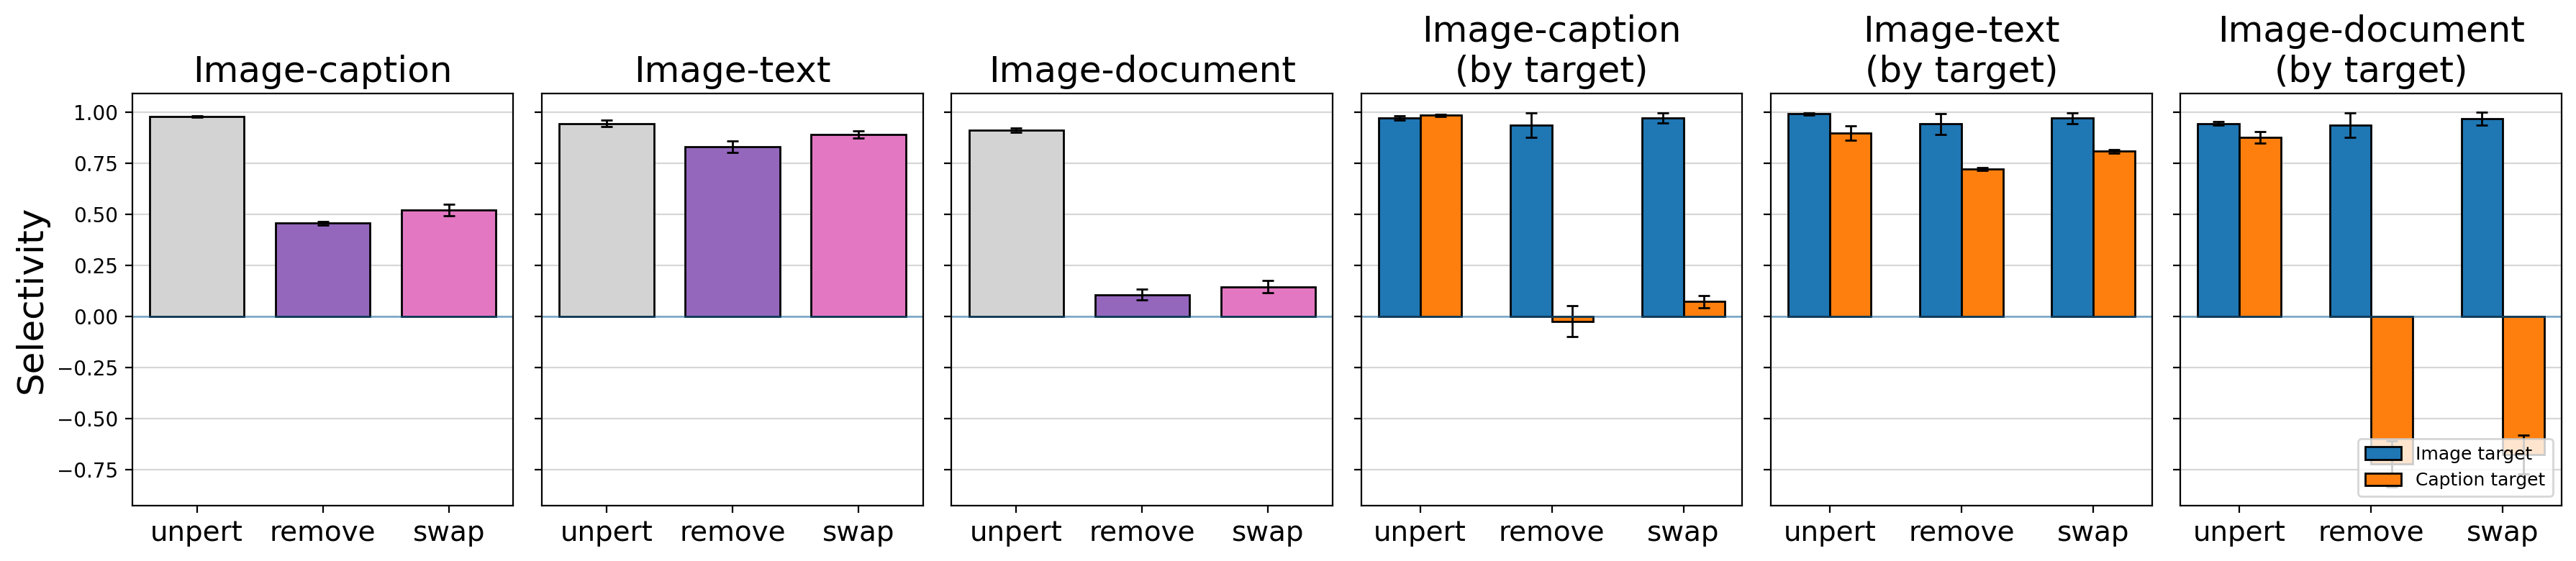

condition       remove  swap  unpert
prompt_format                       
image_caption     0.46  0.52    0.98
image_document    0.11  0.15    0.91
image_text        0.83  0.89    0.94


In [6]:
FORMATS = ["image_caption", "image_text", "image_document"]
FORMAT_LABELS = {"image_caption": "Image-caption", "image_text": "Image-text",
                 "image_document": "Image-document"}
FIG5_MODEL = "Qwen2.5-VL-32B"
sub5 = behavioral.query("input_type == 'inconsistent'")
sub5 = sub5[sub5["model_disp"] == FIG5_MODEL]

fig, axes = plt.subplots(1, len(FORMATS) * 2, figsize=(3.0 * len(FORMATS) * 2, 4.0),
                         dpi=200, sharey=True)
rows5 = []
for k, pf in enumerate(FORMATS):
    s = sub5[sub5["prompt_format"] == pf]
    ax = axes[k]
    vals = [sel_mean(s[s["condition"] == c]) for c in CONDS3]
    errs = [sel_err(s[s["condition"] == c]) for c in CONDS3]
    bars = ax.bar(range(3), vals, yerr=errs, capsize=CAPSIZE, width=BAR_WIDTH,
                  error_kw=dict(ecolor="black", lw=1))
    for b, col in zip(bars, [UNPERT_COLOR, REMOVE_COLOR, SWAP_COLOR]):
        b.set_facecolor(col); b.set_edgecolor(EDGECOLOR); b.set_linewidth(LINEWIDTH)
    ax.axhline(0.0, linewidth=1, alpha=0.5)
    ax.set_title(FORMAT_LABELS[pf], fontsize=18)
    ax.set_xticks(range(3)); ax.set_xticklabels(XLAB3, ha="center", fontsize=14)
    ax.yaxis.grid(True, linestyle="-", alpha=0.5); ax.set_axisbelow(True)
    rows5 += [{"prompt_format": pf, "condition": c, "S": v} for c, v in zip(XLAB3, vals)]

    axr = axes[len(FORMATS) + k]
    w = BAR_WIDTH * 0.42
    for sign, tgt, col in [(-1, "image", IMAGE_TGT_COLOR), (+1, "text", CAPTION_TGT_COLOR)]:
        v = [sel_mean(s[(s["condition"] == c) & (s["target_modality"] == tgt)]) for c in CONDS3]
        e = [sel_err(s[(s["condition"] == c) & (s["target_modality"] == tgt)]) for c in CONDS3]
        axr.bar([i + sign * w / 2 for i in range(3)], v, yerr=e, width=w, capsize=CAPSIZE,
                color=col, edgecolor=EDGECOLOR, linewidth=LINEWIDTH,
                error_kw=dict(ecolor="black", lw=1))
    axr.axhline(0.0, linewidth=1, alpha=0.5)
    axr.set_title(FORMAT_LABELS[pf] + "\n(by target)", fontsize=18)
    axr.set_xticks(range(3)); axr.set_xticklabels(XLAB3, ha="center", fontsize=14)
    axr.yaxis.grid(True, linestyle="-", alpha=0.5); axr.set_axisbelow(True)

axes[0].set_ylabel(r"Selectivity", fontsize=18)
axes[-1].legend(handles=[Patch(facecolor=IMAGE_TGT_COLOR, edgecolor=EDGECOLOR, label="Image target"),
                         Patch(facecolor=CAPTION_TGT_COLOR, edgecolor=EDGECOLOR, label="Caption target")],
                fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

print(pd.DataFrame(rows5).pivot(index="prompt_format", columns="condition",
                                values="S").round(2).to_string())

## Figure 6 — the freeze-remove (Frz-RM) intervention

Restoring contextualized content-token activations into a marker-removed run
partially recovers selectivity, showing that marker information propagates into
the content tokens during contextualization.

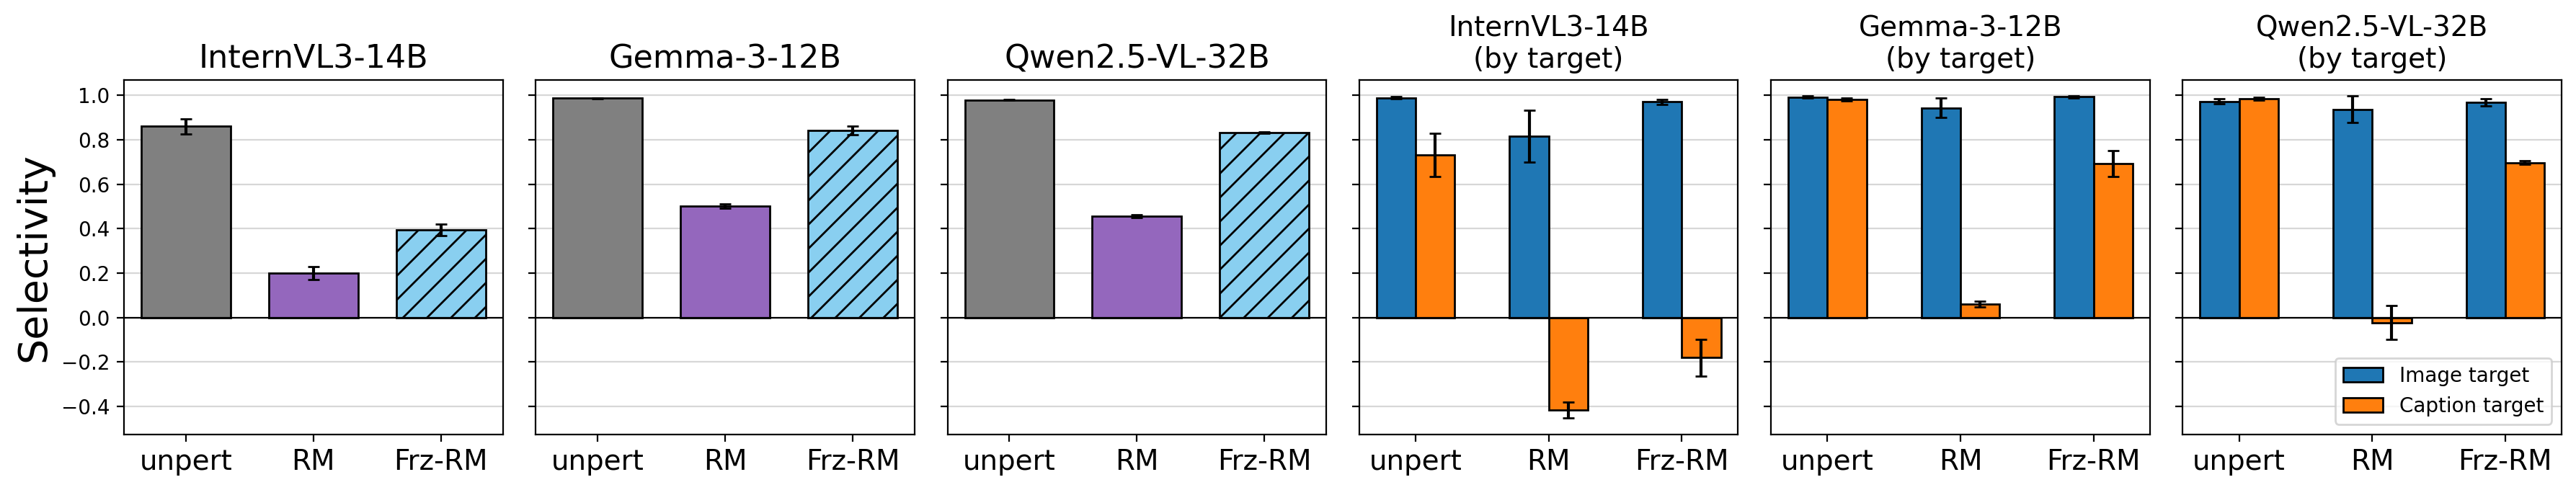

target                    image  text
model          condition             
Gemma-3-12B    Frz-RM      0.99  0.69
               RM          0.94  0.06
               unpert      0.99  0.98
InternVL3-14B  Frz-RM      0.97 -0.18
               RM          0.82 -0.42
               unpert      0.99  0.73
Qwen2.5-VL-32B Frz-RM      0.97  0.70
               RM          0.94 -0.02
               unpert      0.97  0.98


In [7]:
FRZ_CONDS = ["none", "remove", "freeze_content_remove"]
FRZ_ABBV = ["unpert", "RM", "Frz-RM"]
FRZ_COLOR = {"none": "grey", "remove": "C4", "freeze_content_remove": "#89cff0"}
FRZ_HATCH = {"none": None, "remove": None, "freeze_content_remove": "//"}

fig, axes = plt.subplots(1, len(fig4_models) * 2, figsize=(3 * len(fig4_models) * 2, 3.5),
                         sharey=True, dpi=200)
rows6 = []
for k, model in enumerate(fig4_models):
    sub = marker_df[marker_df["model_disp"] == model]
    ax = axes[k]
    for i, cond in enumerate(FRZ_CONDS):
        ax.bar(i, sel_mean(sub[sub["condition"] == cond]),
               yerr=sel_err(sub[sub["condition"] == cond], err="sem"),
               color=FRZ_COLOR[cond], hatch=FRZ_HATCH[cond],
               edgecolor="black", capsize=CAPSIZE, width=0.7)
    ax.set_title(model, fontsize=16)
    ax.set_xticks(range(3)); ax.set_xticklabels(FRZ_ABBV, fontsize=14)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.yaxis.grid(True, linestyle="-", alpha=0.5); ax.set_axisbelow(True)

    axs = axes[len(fig4_models) + k]
    w = 0.7 * 0.42
    for sign, tgt, col in [(-1, "image", IMAGE_TGT_COLOR), (+1, "text", CAPTION_TGT_COLOR)]:
        v = [sel_mean(sub[(sub["condition"] == c) & (sub["target_modality"] == tgt)])
             for c in FRZ_CONDS]
        e = [sel_err(sub[(sub["condition"] == c) & (sub["target_modality"] == tgt)])
             for c in FRZ_CONDS]
        axs.bar([i + sign * w / 2 for i in range(3)], v, yerr=e, width=w,
                color=col, edgecolor="black", capsize=CAPSIZE)
        rows6 += [{"model": model, "condition": c, "target": tgt, "S": x}
                  for c, x in zip(FRZ_ABBV, v)]
    axs.set_title(model + "\n(by target)", fontsize=14)
    axs.set_xticks(range(3)); axs.set_xticklabels(FRZ_ABBV, fontsize=14)
    axs.axhline(0, color="black", linewidth=0.8)
    axs.yaxis.grid(True, linestyle="-", alpha=0.5); axs.set_axisbelow(True)

axes[0].set_ylabel("Selectivity", fontsize=20)
axes[-1].legend(handles=[Patch(facecolor=IMAGE_TGT_COLOR, edgecolor="black", label="Image target"),
                         Patch(facecolor=CAPTION_TGT_COLOR, edgecolor="black", label="Caption target")],
                fontsize=10, loc="lower right")
plt.tight_layout()
plt.show()

print(pd.DataFrame(rows6).pivot_table(index=["model", "condition"], columns="target",
                                      values="S").round(2).to_string())

## Figures 8, 14, 15 and 16 — learned transformation vectors

Selectivity after adding trained vectors at a given relative layer depth,
averaged over the three training seeds with shaded standard deviation. Values
below zero mean the model has been driven to report the non-queried modality.
`Content` and `Marker` are the conditions of interest; the two dashed baselines
add the vector at the first or last token position instead (Appendix L.2). The
grey dashed line is the uninterventioned model and the dotted maroon line the
token-level marker-swap reference.

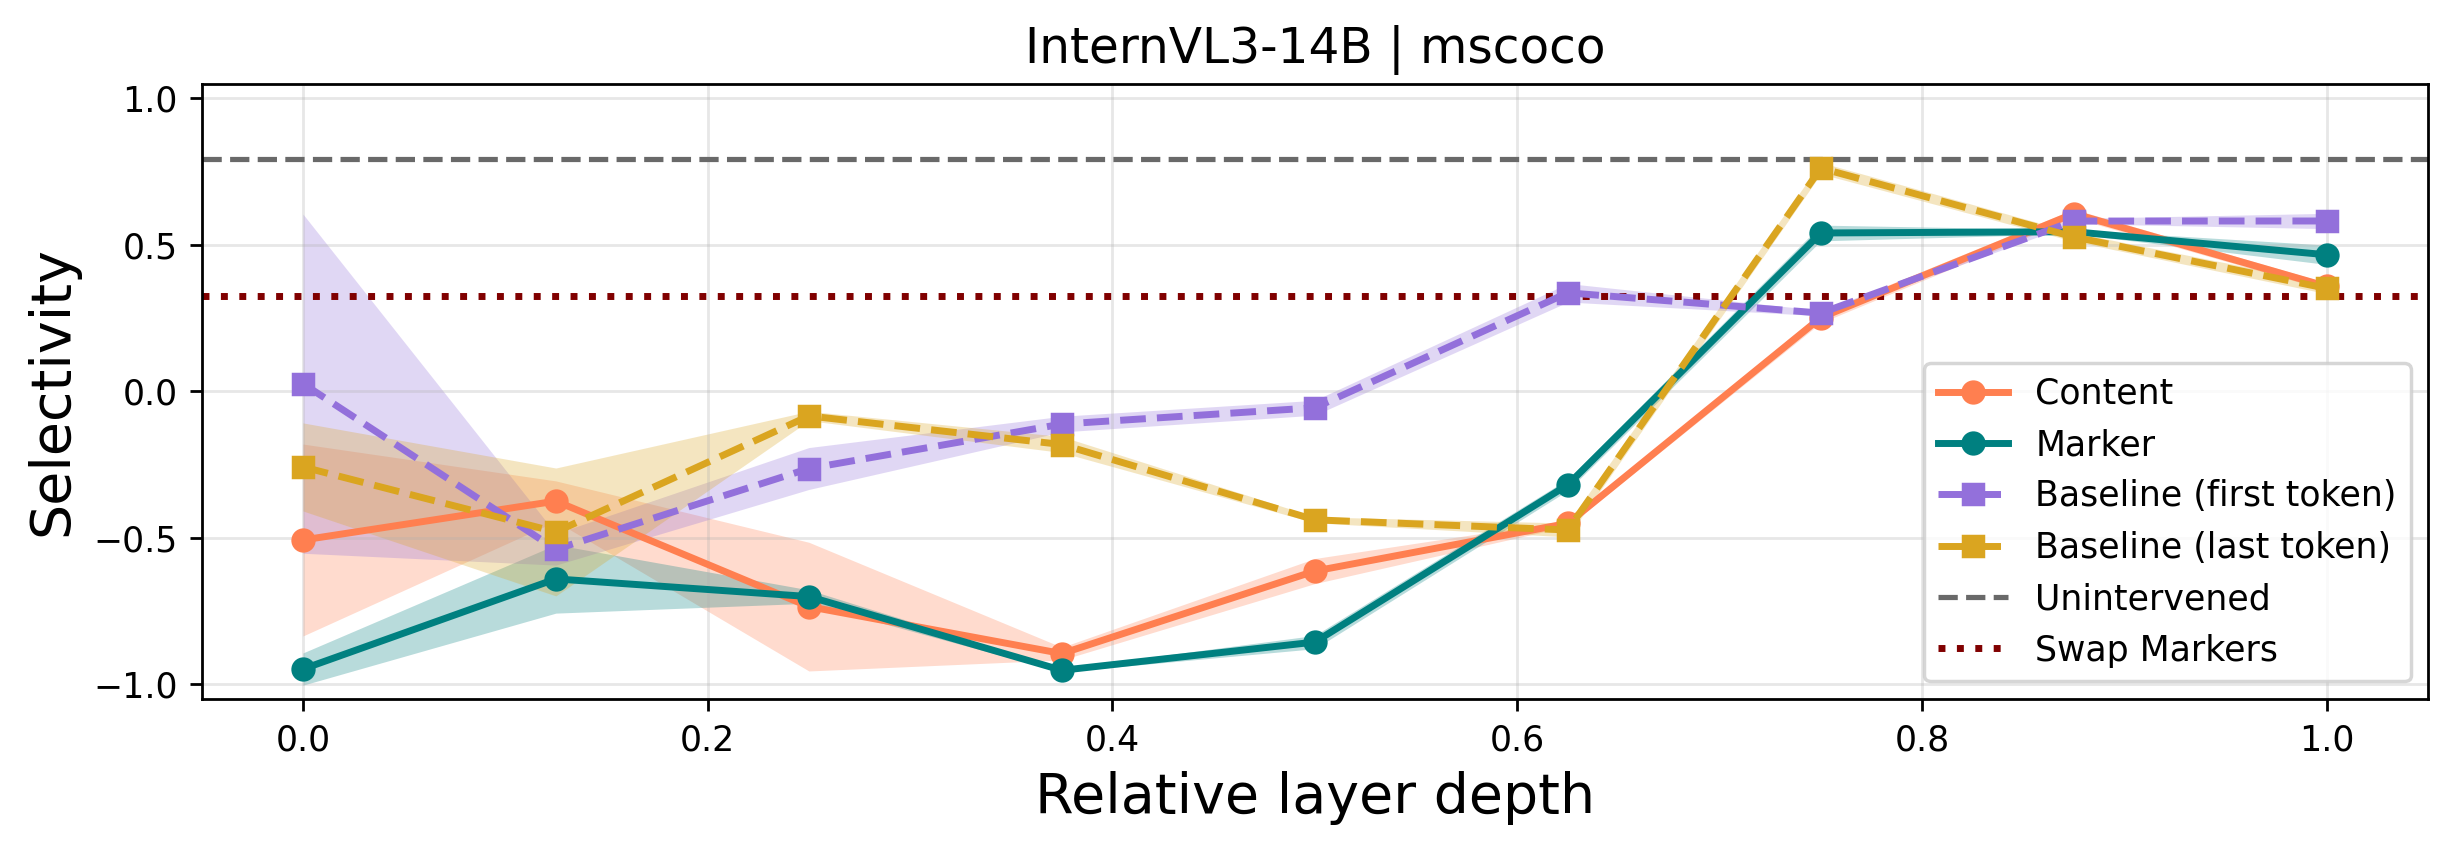

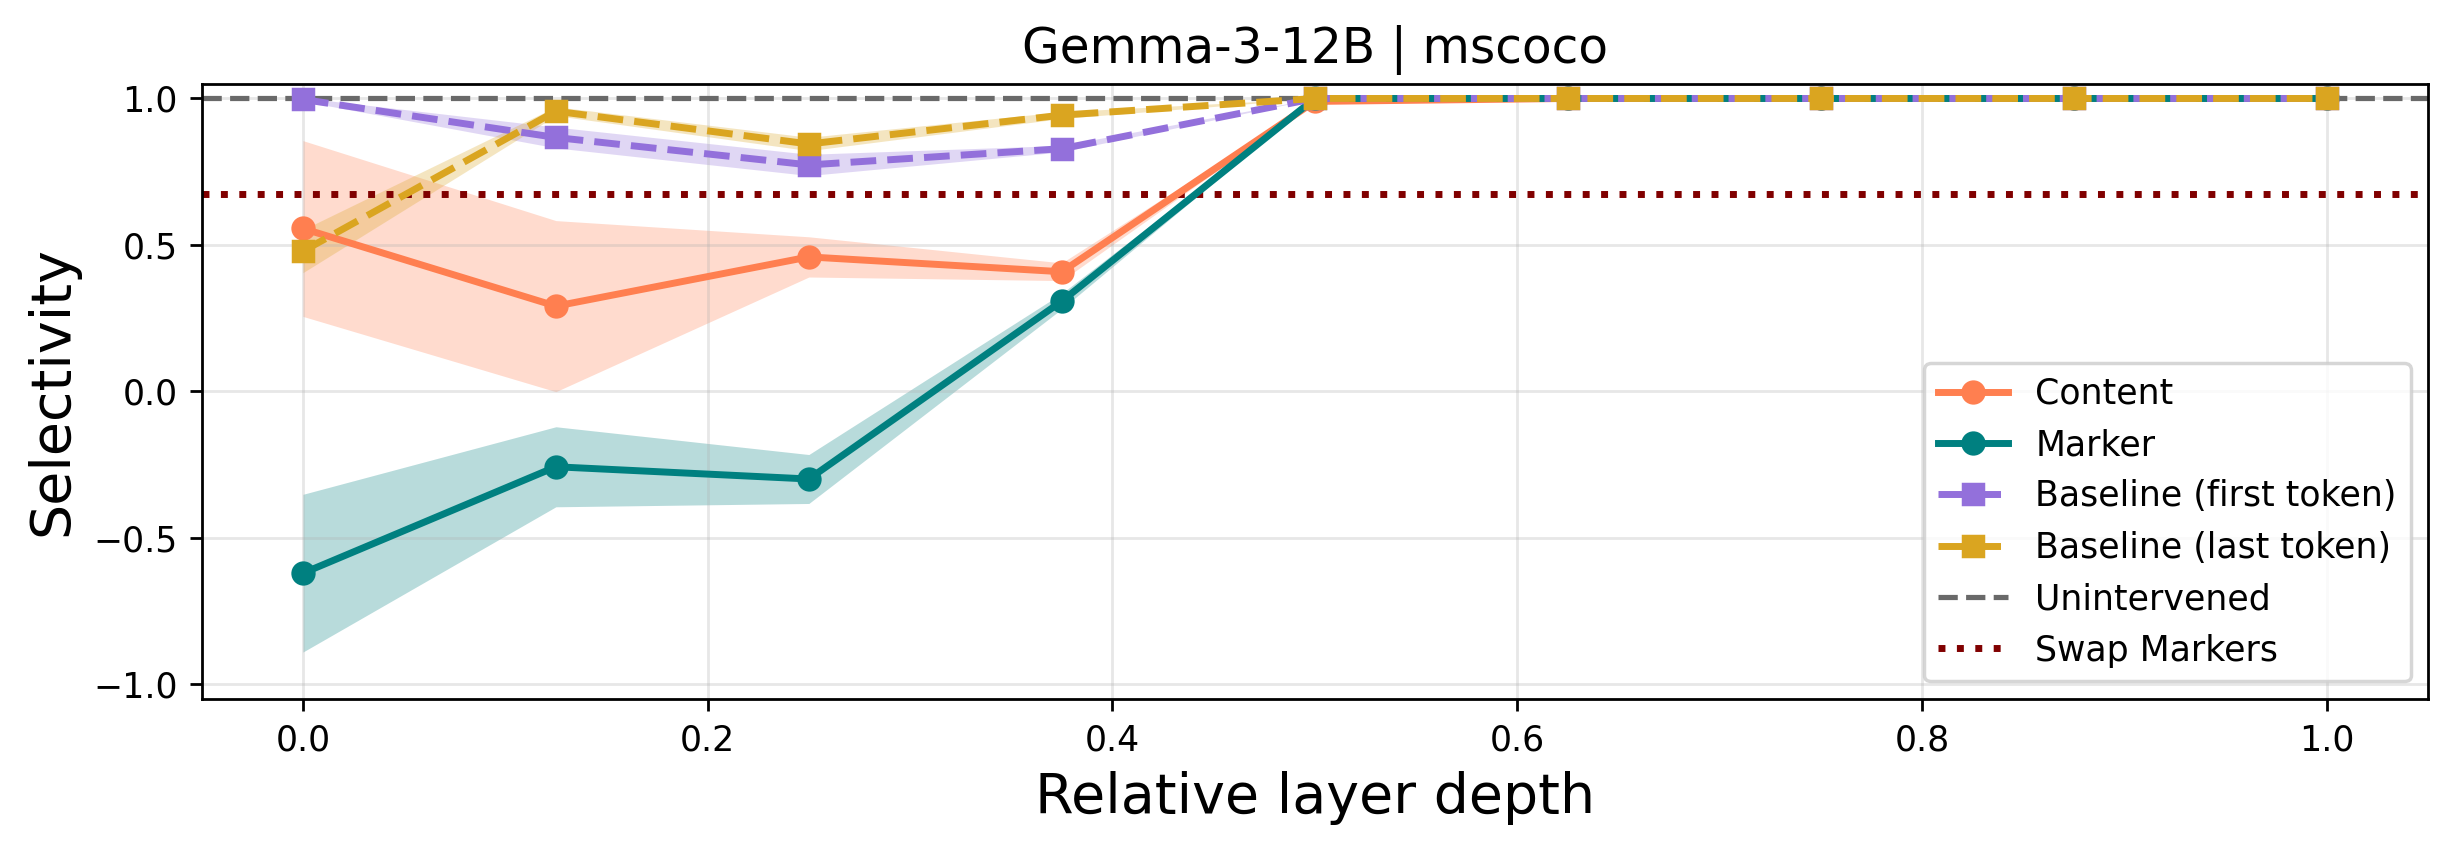

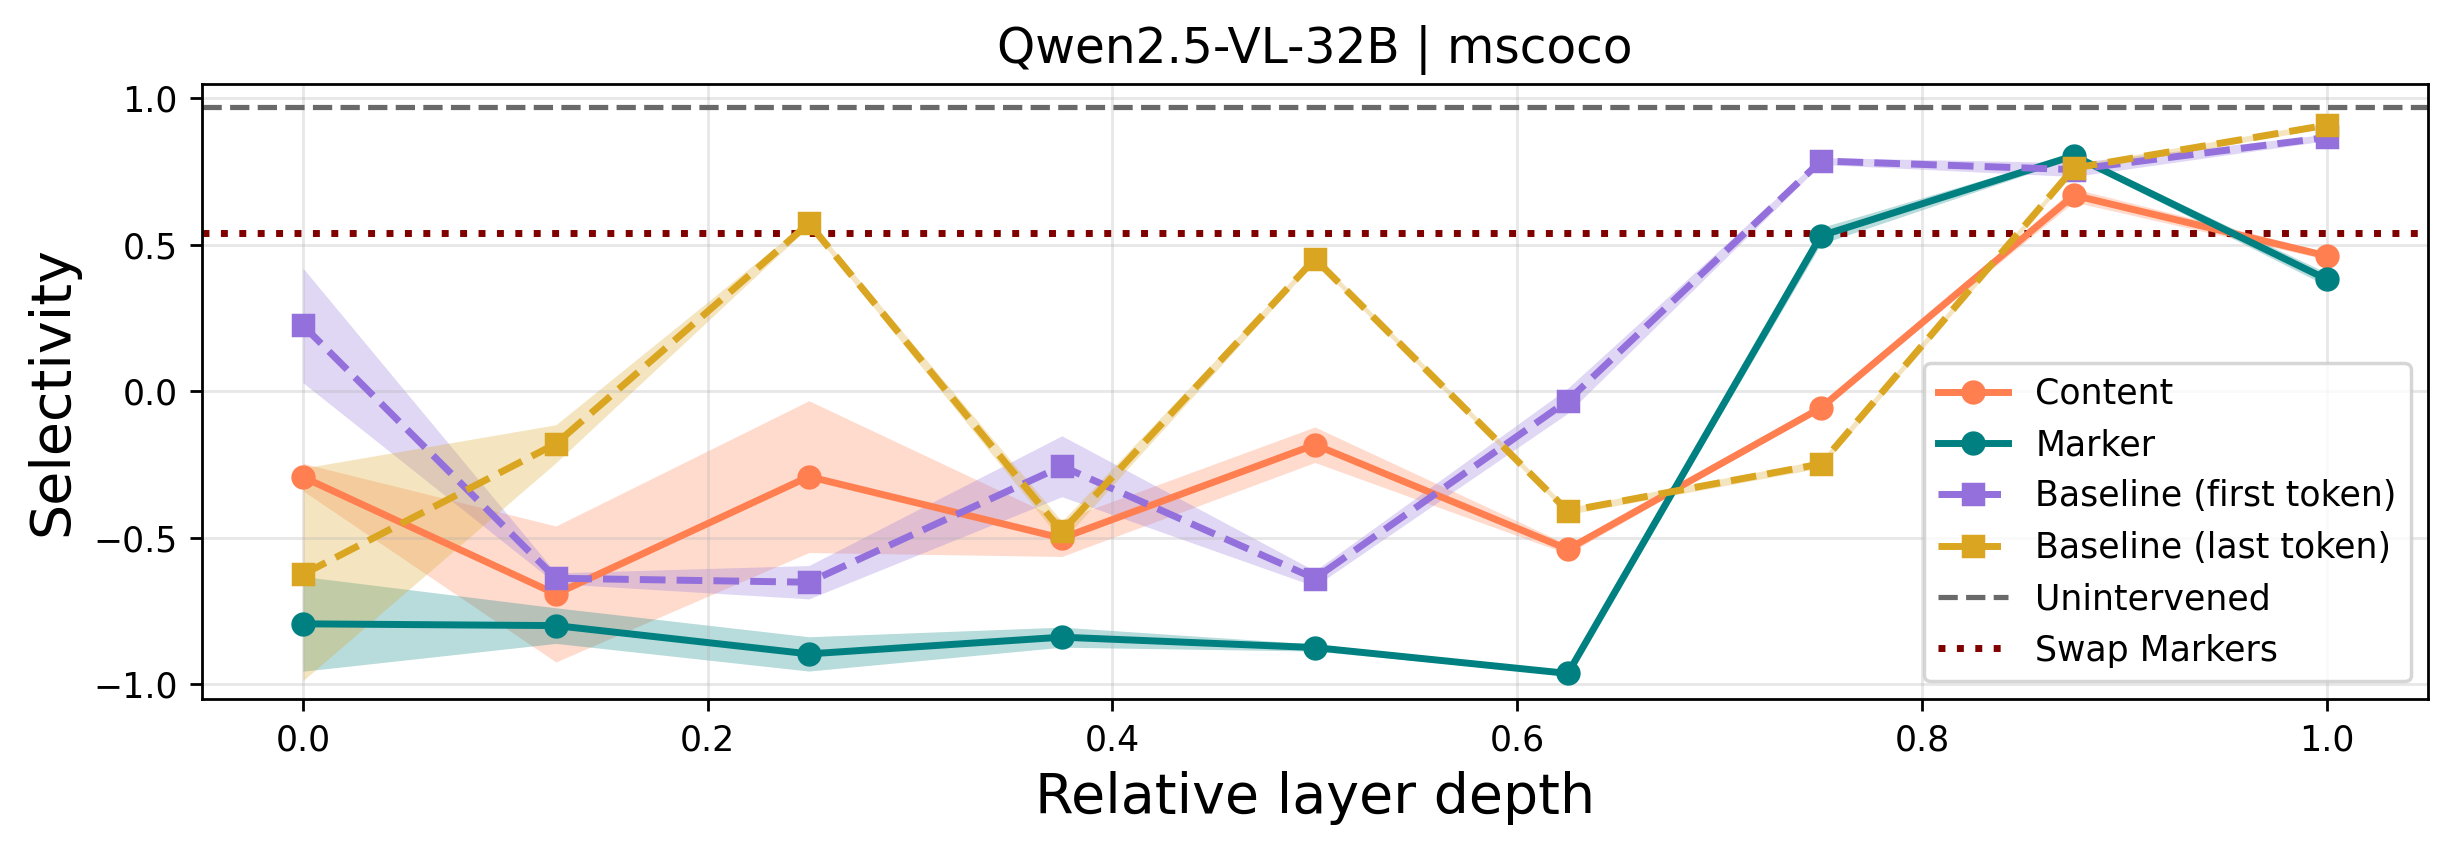

depth                          0.000  0.125  0.250  0.375  0.500  0.625  0.750  0.875  1.000
model          span                                                                         
Gemma-3-12B    baseline_first   1.00   0.87   0.77   0.83   1.00   1.00   1.00   1.00   1.00
               baseline_last    0.48   0.96   0.84   0.94   1.00   1.00   1.00   1.00   1.00
               content          0.56   0.29   0.46   0.41   0.99   1.00   1.00   1.00   1.00
               marker          -0.62  -0.26  -0.30   0.31   1.00   1.00   1.00   1.00   1.00
InternVL3-14B  baseline_first   0.03  -0.54  -0.26  -0.11  -0.06   0.34   0.27   0.58   0.58
               baseline_last   -0.26  -0.48  -0.08  -0.18  -0.44  -0.47   0.76   0.53   0.35
               content         -0.51  -0.37  -0.74  -0.90  -0.61  -0.45   0.25   0.61   0.36
               marker          -0.95  -0.64  -0.70  -0.95  -0.86  -0.32   0.54   0.55   0.47
Qwen2.5-VL-32B baseline_first   0.23  -0.64  -0.65  -0.26  -0.64  -0.0

In [8]:
TVEC_COLORS = {"content": "coral", "marker": "teal",
               "baseline_first": "mediumpurple", "baseline_last": "goldenrod"}
TVEC_LABELS = {"content": "Content", "marker": "Marker",
               "baseline_first": "Baseline (first token)", "baseline_last": "Baseline (last token)"}
interv = transform[transform["arm"] == "intervention"]
base = transform[transform["arm"] == "baseline"]

# Swap-marker reference: MSCOCO, image_caption, mean of per-run selectivity.
swap_ref = {m: sel_mean(behavioral.query(
    "condition == 'swap' and input_type == 'inconsistent' and "
    "prompt_format == 'image_caption' and dataset == 'mscoco'")
    .pipe(lambda d: d[d["model_disp"] == m])) for m in fig4_models}

rows8 = []
for model in fig4_models:
    fig, ax = plt.subplots(1, 1, figsize=(10, 3.5), dpi=250)
    for span in ["content", "marker", "baseline_first", "baseline_last"]:
        sub = interv[(interv["model_disp"] == model) & (interv["intervention"] == span)]
        if sub.empty:
            continue
        per_seed = (sub.groupby(["layer_depth", "seed"]).apply(sel_pooled, include_groups=False)
                    .rename("S").reset_index())
        agg = per_seed.groupby("layer_depth")["S"].agg(["mean", "std"]).fillna(0.0).sort_index()
        xv, mv, ev = agg.index.values, agg["mean"].values, agg["std"].values
        col = TVEC_COLORS[span]
        dashed = span.startswith("baseline")
        ax.fill_between(xv, mv - ev, mv + ev, color=col, alpha=0.28, linewidth=0, zorder=1)
        ax.plot(xv, mv, "s--" if dashed else "o-", color=col, linewidth=2, markersize=6,
                label=TVEC_LABELS[span], zorder=3)
        rows8 += [{"model": model, "span": span, "depth": d, "S": v} for d, v in zip(xv, mv)]

    ref = base[(base["model_disp"] == model) & (base["intervention"] == "marker")]
    if not ref.empty:
        ax.axhline(sel_pooled(ref), color="dimgray", linestyle="--", linewidth=1.5,
                   label="Unintervened", zorder=2)
    if not np.isnan(swap_ref[model]):
        ax.axhline(swap_ref[model], color="maroon", linestyle=":", linewidth=2,
                   label="Swap Markers", zorder=2)

    ax.set_xlabel("Relative layer depth", fontsize=16)
    ax.set_ylabel("Selectivity", fontsize=16)
    ax.set_ylim(-1.05, 1.05)
    ax.grid(True, alpha=0.3, zorder=0)
    ax.legend(loc="best", fontsize=10)
    ax.set_title(f"{model} | mscoco", fontsize=14)
    plt.tight_layout()
    plt.show()

print(pd.DataFrame(rows8).pivot_table(index=["model", "span"], columns="depth",
                                      values="S").round(2).to_string())

## Table 6 — distributional separation of image and text tokens

Cosine rows give the mean and standard deviation across the 16 model-dataset
pairs; probe rows give the mean cross-validation score and the mean of the
per-run CV standard errors, matching the caption of Table 6.

In [9]:
r = represent
within = (r["within_image_cos"] + r["within_caption_cos"]) / 2
table6 = pd.DataFrame([
    ("Within-image cosine similarity", r["within_image_cos"].mean(), r["within_image_cos"].std()),
    ("Within-caption cosine similarity", r["within_caption_cos"].mean(), r["within_caption_cos"].std()),
    ("Average within-modality cosine similarity", within.mean(), within.std()),
    ("Cross-modality cosine similarity", r["across_modality_cos"].mean(), r["across_modality_cos"].std()),
    ("Linear probe accuracy (3-fold CV)", r["probe_cv_accuracy"].mean(), r["probe_cv_accuracy_std"].mean()),
    ("Control: shuffled labels", r["control_cv_accuracy"].mean(), r["control_cv_accuracy_std"].mean()),
], columns=["Metric", "Mean", "Std"]).set_index("Metric")
print(f"across {len(r)} model-dataset pairs\n")
print(table6.round(3).to_string())

across 16 model-dataset pairs

                                            Mean    Std
Metric                                                 
Within-image cosine similarity             0.325  0.093
Within-caption cosine similarity           0.101  0.039
Average within-modality cosine similarity  0.213  0.064
Cross-modality cosine similarity           0.020  0.018
Linear probe accuracy (3-fold CV)          0.999  0.001
Control: shuffled labels                   0.491  0.018
